## Prep

- Install packages
- Decompress `data.tar.gz` to a child directory `data`

In [4]:
! conda install -y numpy pandas nltk matplotlib gensim scikit-learn

^C


Channels:
 - defaults
 - conda-forge
 - gurobi
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: E:\Anaconda

  added / updated specs:
    - gensim
    - matplotlib
    - nltk
    - numpy
    - pandas
    - scikit-learn


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2024.9.24  |       haa95532_0         131 KB
    conda-24.9.1               |  py312haa95532_0         1.2 MB
    gensim-4.3.3               |  py312h0158946_0        42.3 MB
    matplotlib-3.9.2           |  py312haa95532_0           8 KB
    matplotlib-base-3.9.2      |  py312hbdc63d0_0         7.8 MB
    nltk-3.9.1                 |  py312haa95532_0         2.7 MB
    scikit-learn-1.5.1         |  py312h0158946_0         9.3 MB
    threadpoolctl-3.5.0        |  py312hfc267ef_0          49 KB
    ----------------------------------------------------------

In [2]:
! conda install -y -c conda-forge wordcloud

Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 4.11.0
  latest version: 24.9.0

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /home/jl/miniconda3/envs/ubcp1

  added / updated specs:
    - wordcloud


The following packages will be SUPERSEDED by a higher-priority channel:

  ca-certificates    pkgs/main::ca-certificates-2024.9.24-~ --> conda-forge::ca-certificates-2024.8.30-hbcca054_0
  certifi            pkgs/main/linux-64::certifi-2024.8.30~ --> conda-forge/noarch::certifi-2024.8.30-pyhd8ed1ab_0


Preparing transaction: done
Verifying transaction: done
Executing transaction: done


In [3]:
# import packages
from collections import Counter
import numpy as np
import pandas as pd
import nltk
import string
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from sklearn.feature_extraction.text import TfidfVectorizer

## Part 1

### A1

In [4]:
industry_code = 80  # health services
df1 = pd.read_csv("data/major_groups.csv")
df1[df1.major_group == industry_code]

,major_group,description
66,80,Health Services


### A2

In [6]:
df2 = pd.read_csv("data/public_firms.csv")
df_filtered = df2[df2['sic'].astype(str).str.startswith(str(industry_code))]
df_filtered 

,gvkey,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa
1588,1431,1994,USA,AMERICAN CYTOGENETICS,NaN,8071,NaN,0.035,-0.205,1.339,5.454,-0.153099
1589,1431,1995,USA,AMERICAN CYTOGENETICS,NaN,8071,0.031,0.020,-0.484,1.124,4.682,-0.430605
2064,1559,1995,USA,AMERICAN SHARED HSPTL SERV,NaN,8090,1.312,0.452,7.344,31.345,34.077,0.234296
2065,1559,1996,USA,AMERICAN SHARED HSPTL SERV,NaN,8090,1.812,0.368,-0.353,32.969,36.989,-0.010707
2066,1559,1997,USA,AMERICAN SHARED HSPTL SERV,NaN,8090,1.750,0.017,1.522,30.209,37.172,0.050382
...,...,...,...,...,...,...,...,...,...,...,...,...
207946,265008,2011,USA,21ST CENTURY ONCOLOGY HLDGS,2004/06/18,8090,NaN,10.177,-353.441,998.592,644.717,-0.353939
207947,265008,2012,USA,21ST CENTURY ONCOLOGY HLDGS,2004/06/18,8090,NaN,15.410,-154.208,922.301,693.951,-0.167199
207948,265008,2013,USA,21ST CENTURY ONCOLOGY HLDGS,2004/06/18,8090,NaN,17.462,-80.214,1128.191,736.516,-0.071100
207949,265008,2014,USA,21ST CENTURY ONCOLOGY HLDGS,2004/06/18,8090,NaN,99.082,-357.291,1153.444,1018.182,-0.309760


### A3

In [7]:
#A3a
num_fyear = df_filtered.fyear.nunique() 
print(f"Number of unique firm-year: {num_fyear}")

Number of unique firm-year: 27


In [8]:
#A3b
num_com = df_filtered.conm.nunique() 
print(f"Number of unique firms: {num_com}")

Number of unique firms: 358


In [9]:
#A3c
company_years_count = df_filtered.groupby('conm')['fyear'].nunique()
companies_all_years = company_years_count[company_years_count == 27]
num_firms = companies_all_years.shape[0]
print(f"Number of firms with records over all 27 years: {num_firms}")

Number of firms with records over all 27 years: 2


### B1

In [10]:
#B1 Top 10 firms with the highest stock price in the year 2020
df_2020 = df_filtered[df_filtered['fyear'] == 2020]
df_top_10 = df_2020.sort_values(by='prcc_c', ascending=False).head(10)
top_10_firms = df_top_10[['conm', 'prcc_c']]
print(top_10_firms)

                               conm  prcc_c
7723                    CHEMED CORP  532.61
107521                 AMEDISYS INC  293.33
183851                LHC GROUP INC  213.32
58187   LABORATORY CP OF AMER HLDGS  203.55
82137            TELADOC HEALTH INC  199.96
77060            HCA HEALTHCARE INC  164.46
41013     UNIVERSAL HEALTH SVCS INC  137.50
87614      U S PHYSICAL THERAPY INC  120.25
135469        QUEST DIAGNOSTICS INC  119.17
121189                   DAVITA INC  117.40


### B2

In [11]:
#B2 Top 10 firms with the highest sales in the entire history of the dataset
df_top_10_sales = df_filtered.sort_values(by='sale', ascending=False).head(10)
top_10_firms_sales = df_top_10_sales[['conm', 'sale']]
print(top_10_firms_sales)

                     conm     sale
77060  HCA HEALTHCARE INC  51533.0
77059  HCA HEALTHCARE INC  51336.0
77058  HCA HEALTHCARE INC  46677.0
77057  HCA HEALTHCARE INC  43614.0
77056  HCA HEALTHCARE INC  41490.0
77055  HCA HEALTHCARE INC  39678.0
77054  HCA HEALTHCARE INC  36918.0
77053  HCA HEALTHCARE INC  34182.0
77052  HCA HEALTHCARE INC  33013.0
77050  HCA HEALTHCARE INC  30683.0


### B3

In [12]:
#B3 Top 10 locations
location_distribution = df_filtered.groupby('location').size()
top_10_locations = location_distribution.sort_values(ascending=False).head(10)
print(top_10_locations)

location
USA    2955
CAN      31
CHN      30
DEU      26
HKG      21
AUS       1
dtype: int64


### B4

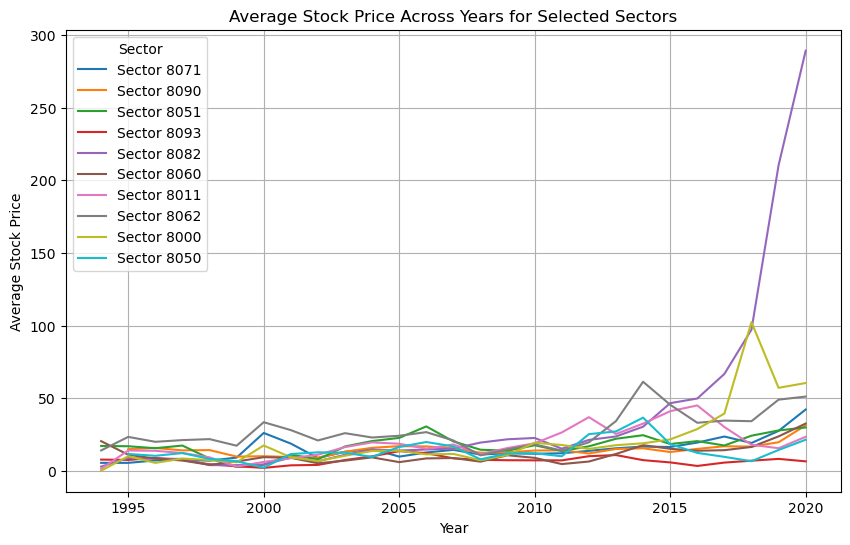

In [13]:
#B4 Line chart of the average stock price 

df_sector = df_filtered.copy()

df_avg_stock_price = df_sector.groupby(['sic', 'fyear'])['prcc_c'].mean().reset_index()

# Create a line plot for each sector
plt.figure(figsize=(10, 6))

for sector in df_sector.sic.unique():
    df_sector_filtered = df_avg_stock_price[df_avg_stock_price['sic'] == sector]
    plt.plot(df_sector_filtered['fyear'], df_sector_filtered['prcc_c'], label=f'Sector {sector}')

# Add labels and title
plt.xlabel('Year')
plt.ylabel('Average Stock Price')
plt.title('Average Stock Price Across Years for Selected Sectors')
plt.legend(title='Sector')
plt.grid(True)

plt.show()


### B5

In [14]:
#B5 Firm was affected the most by the 2008 Financial Crisis
df_2007 = df_filtered[df_filtered['fyear'] == 2007][['conm', 'prcc_c']]
df_2008 = df_filtered[df_filtered['fyear'] == 2008][['conm', 'prcc_c']]
df_merged = pd.merge(df_2007, df_2008, on='conm', suffixes=('_2007', '_2008'))

# Calculate the percentage drop in stock price from 2007 to 2008
df_merged['perc_drop'] = ((df_merged['prcc_c_2007'] - df_merged['prcc_c_2008']) / df_merged['prcc_c_2007']) * 100
df_most_affected = df_merged.sort_values(by='perc_drop', ascending=False).head(1)

print(df_most_affected[['conm', 'prcc_c_2007', 'prcc_c_2008', 'perc_drop']])


                           conm  prcc_c_2007  prcc_c_2008  perc_drop
81  INSIGHT HEALTH SVCS HLDG CP          3.0         0.02  99.333333


### B6

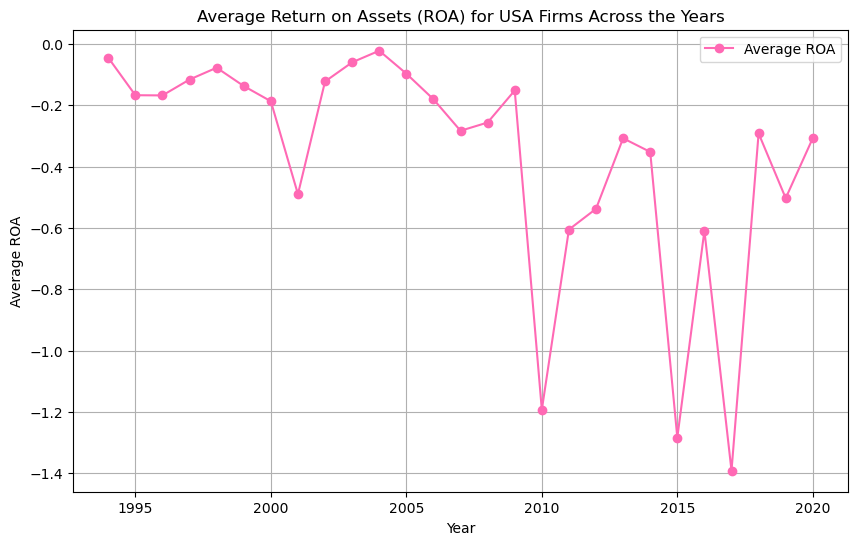

In [15]:
#B6 ROA of the firms located in the “USA” across the years
# Filter the data for firms located in the USA
df_usa = df_filtered[df_filtered['location'] == 'USA'].copy()

# Calculate ROA
df_usa['roa'] = df_usa['ni'] / df_usa['asset']
df_avg_roa = df_usa.groupby('fyear')['roa'].mean().reset_index()

# Plot the average ROA across the years
plt.figure(figsize=(10, 6))
plt.plot(df_avg_roa['fyear'], df_avg_roa['roa'], marker='o', color='#FF69B4', label='Average ROA')

# Add labels and title
plt.xlabel('Year')
plt.ylabel('Average ROA')
plt.title('Average Return on Assets (ROA) for USA Firms Across the Years')
plt.grid(True)
plt.legend()

plt.show()


## Part 2
### C

In [17]:
df_10k = pd.read_csv('data/2020_10K_item1_full.csv')
# remove duplicate firms, important for model training, 5400+ rows -> 5152 rows
df_10k.drop_duplicates(inplace=True, ignore_index=True)
df_10k

,cik,year,name,item_1_text,gvkey
0,1041588,2020,ACCESS-POWER INC,fixed expenses are previosuly documented in an...,66119
1,315374,2020,HURCO COMPANIES INC,"General Hurco Companies, Inc. is an internatio...",5788
2,1622996,2020,"ACRO BIOMEDICAL CO., LTD.",We have been engaged in the business of develo...,27584
3,1191334,2020,Chun Can Capital Group,CORPORATE HISTORY Chun Can Capital Group (form...,153614
4,1593204,2020,Adaiah Distribution Inc,General Adaiah Distribution Inc. was incorpora...,23706
...,...,...,...,...,...
5147,740664,2020,R F INDUSTRIES LTD,"General RF Industries, Ltd. (together with sub...",2829
5148,1074828,2020,"KNOW LABS, INC.","BACKGROUND AND CAPITAL STRUCTURE Know Labs, In...",166430
5149,40570,2020,GEE Group Inc.,"General GEE Group Inc. (the Company , us , ...",5050
5150,1341726,2020,"GULFSLOPE ENERGY, INC.","General GulfSlope Energy, Inc. is an independe...",175595


In [18]:
nltk.download('stopwords')
eng_stopwords = set(nltk.corpus.stopwords.words('english'))
translator = str.maketrans('', '', string.punctuation + '•')

def clean_text(text: str) -> str:
    ''' 
    This function takes a string as input and 
    returns a cleaned version of the string
    Specifically, it makes the string into lower case, and remove punctuations and stopwords
    '''
    text_lower = text.lower() # make it lowercase
    text_no_punctuation = text_lower.translate(translator) # remove punctuation  
    clean_words = [w for w in text_no_punctuation.split() if w not in eng_stopwords] # remove stopwords
    return ' '.join(clean_words)

df_10k['item_1_cleaned'] = df_10k['item_1_text'].apply(clean_text)

[nltk_data] Downloading package stopwords to /home/jl/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### D1

In [20]:
df_firms = df_filtered.copy()  # From part 1

# Do inner join. Since the 10k data is only available in 2020, we join on both company key and year
df = df_firms.merge(df_10k, left_on=["gvkey", "fyear"], right_on=["gvkey", "year"])
df

,gvkey,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa,cik,year,name,item_1_text,item_1_cleaned
0,1559,2020,USA,AMERICAN SHARED HSPTL SERV,NaN,8090,2.2200,3.961,-7.058,43.653,17.837,-0.161684,744825,2020,AMERICAN SHARED HOSPITAL SERVICES,GENERAL American Shared Hospital Services ( AS...,general american shared hospital services ashs...
1,2960,2020,USA,CHEMED CORP,NaN,8082,532.6100,162.675,319.466,1434.911,2079.583,0.222638,19584,2020,CHEMED CORP,General Chemed Corporation (the Company or Che...,general chemed corporation company chemed inco...
2,4418,2020,USA,ENZO BIOCHEM INC,NaN,8071,2.5200,47.865,-28.520,112.538,74.525,-0.253426,316253,2020,ENZO BIOCHEM INC,"Overview Enzo Biochem, Inc. (the Company we...",overview enzo biochem inc company enzo integra...
3,4826,2020,USA,FONAR CORP,1987/01/01,8071,17.3600,36.802,8.240,180.259,85.690,0.045712,355019,2020,FONAR CORP,"GENERAL Fonar Corporation, sometimes referred ...",general fonar corporation sometimes referred c...
4,7741,2020,USA,NATIONAL HEALTHCARE CORP,NaN,8051,66.4100,147.093,41.871,1362.132,977.928,0.030739,1047335,2020,NATIONAL HEALTHCARE CORP,"National HealthCare Corporation, which we also...",national healthcare corporation also refer nhc...
5,7750,2020,USA,TENET HEALTHCARE CORP,NaN,8062,39.9300,2446.000,399.000,27106.000,17640.000,0.014720,70318,2020,TENET HEALTHCARE CORP,OVERVIEW Tenet Healthcare Corporation (togethe...,overview tenet healthcare corporation together...
6,11032,2020,USA,UNIVERSAL HEALTH SVCS INC,NaN,8062,137.5000,1224.490,943.953,13476.879,11145.897,0.070042,352915,2020,UNIVERSAL HEALTH SERVICES INC,Our principal business is owning and operating...,principal business owning operating subsidiari...
7,12304,2020,USA,DLH HOLDINGS CORP,NaN,8090,9.3200,1.357,7.114,183.562,209.185,0.038755,785557,2020,DLH Holdings Corp.,Overview DLH Holdings Corp. is a provider of t...,overview dlh holdings corp provider technology...
8,12589,2020,USA,ENCOMPASS HEALTH CORP,1986/09/30,8060,82.6900,224.000,284.200,6445.900,4644.400,0.044090,785161,2020,Encompass Health Corp,Overview of the Company General We are a leadi...,overview company general leading provider inte...
9,13071,2020,USA,RADNET INC,1986/07/01,8071,19.5700,102.018,-14.840,1786.657,1071.840,-0.008306,790526,2020,"RadNet, Inc.",Business Overview We are a leading national pr...,business overview leading national provider fr...


### D2

In [21]:
def get_keywords_wc(text: str, c: int = 10) -> str:
    '''
    This function gets a string with words separated by spaces, and returns most frequent words in that string.
    Input: text
    Output: The top 10 keywords based on their counts in the input text
    '''
    cnts = Counter(str(text).split())
    words = []
    for k, _ in cnts.most_common(c):
        words.append(k)
    return ' '.join(words)

def get_keywords_tfidf(document_list: list, c: int = 10) -> list:
    '''
    This function gets a list of documents as input and returns a list of top 10 keywords for each document using TF-IDF scores.
    Input: A list of documents (text)
    Output: The corresponding top 10 keywords for each document based on tf-idf values
    '''
    vectorizer = TfidfVectorizer() # Step 1: Create a TF-IDF vectorizer
    tfidf_matrix = vectorizer.fit_transform(document_list) # Step 2: Calculate the TF-IDF matrix
    feature_names = vectorizer.get_feature_names_out() # Step 3: Get feature names (words)

    # Step 4: Extract top 10 keywords for each document
    top_keywords = [] # accumulator
    for i in range(len(document_list)):
        feature_index = tfidf_matrix[i, :].nonzero()[1]
        feature_value = [tfidf_matrix[i, x] for x in feature_index]
        tfidf_scores = zip(feature_index, feature_value)
        sorted_tfidf_scores = sorted(tfidf_scores, key=lambda x: -x[1])
        top_keywords.append(' '.join([feature_names[i] for i, _ in sorted_tfidf_scores[:c]]))
    
    return top_keywords

In [22]:
df['top_keywords_wc'] = df['item_1_cleaned'].apply(get_keywords_wc)

docs = df['item_1_cleaned']
keywords_tfidf = get_keywords_tfidf(list(docs))
df['top_keywords_tfidf'] = keywords_tfidf

In [23]:
df[['conm', 'top_keywords_wc', 'top_keywords_tfidf']]

,conm,top_keywords_wc,top_keywords_tfidf
0,AMERICAN SHARED HSPTL SERV,company gamma knife services radiation therapy...,knife gamma company radiation pbrt gkf bates r...
1,CHEMED CORP,hospice care vitas medicare services programs ...,vitas hospice care medicare rotorooter service...
2,ENZO BIOCHEM INC,clinical products laboratory health enzo servi...,enzo clinical laboratory products fda nucleic ...
3,FONAR CORP,mri fonar hmca services imaging upright® diagn...,mri fonar hmca upright scanners scanner imagin...
4,NATIONAL HEALTHCARE CORP,care facilities nursing services health skille...,nursing skilled care facilities services healt...
5,TENET HEALTHCARE CORP,healthcare services care hospitals conifer hos...,conifer npa hospitals healthcare hospital serv...
6,UNIVERSAL HEALTH SVCS INC,care health hospitals services facilities hosp...,trust hospitals care health behavioral hospita...
7,DLH HOLDINGS CORP,services government health contracts employees...,services va contracts government prime backlog...
8,ENCOMPASS HEALTH CORP,care health medicare home healthcare services ...,hospice home care medicare health rehabilitati...
9,RADNET INC,services imaging diagnostic facilities radiolo...,imaging radiology diagnostic services mri brmg...


### D3

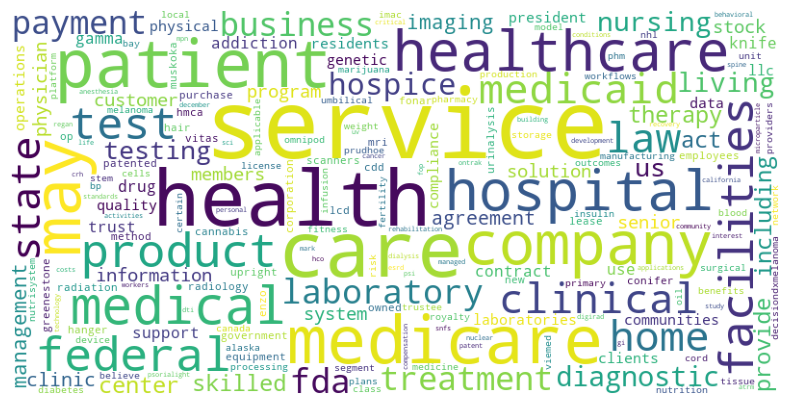

In [24]:
wordcloud_wc = WordCloud(width=800, height=400, max_font_size=100, background_color='white')\
        .generate(' '.join(df['top_keywords_wc'].tolist()))

plt.figure(figsize=(10,5))
plt.axis('off')
plt.imshow(wordcloud_wc)
plt.savefig('keyword_wc.png') # save as PNG file
plt.show()

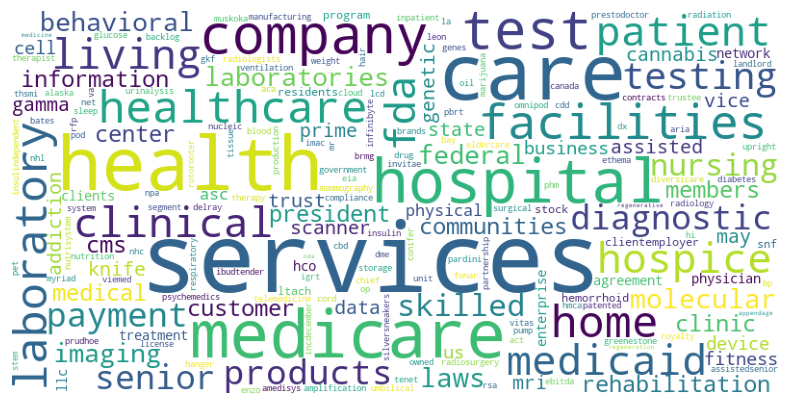

In [25]:
wordcloud_tfidf = WordCloud(width=800, height=400, max_font_size=100, background_color='white')\
        .generate(' '.join(df['top_keywords_tfidf'].tolist()))

plt.figure(figsize=(10,5))
plt.axis('off')
plt.imshow(wordcloud_tfidf)
plt.savefig('keyword_tfidf.png') # save as PNG file
plt.show()

### E1

In [26]:
docs = [row.split() for row in df_10k['item_1_cleaned']]
print(len(docs))

5152


In [27]:
model = Word2Vec(docs, min_count=0, vector_size=128, workers=8, window=5, sg=1)
model.save("word2vec.model")

In [28]:
model = Word2Vec.load("word2vec.model")

### E2

In [29]:
# Choose medicare, hospital, test
k = 5
model.wv.most_similar('medicare')[:k]

[('medicaid', 0.9155111908912659),
 ('cms', 0.8115101456642151),
 ('beneficiaries', 0.8037799596786499),
 ('federallyfunded', 0.7554261684417725),
 ('dualeligible', 0.7452839612960815)]

In [30]:
model.wv.most_similar('hospital')[:k]

[('inpatient', 0.8112481832504272),
 ('outpatient', 0.764403760433197),
 ('hospitals', 0.746023952960968),
 ('readmitted', 0.7446929812431335),
 ('icu', 0.7209174036979675)]

In [31]:
model.wv.most_similar('test')[:k]

[('tests', 0.7751190066337585),
 ('tads', 0.7296106815338135),
 ('nevome', 0.7207460999488831),
 ('ioniq', 0.7172797322273254),
 ('guardantomni', 0.7119888067245483)]

In [32]:
# We use tfidf embeddings only, because these keywords are more specific to individual firms 
doc_embs_tfidf = []
for _, row in df.iterrows():
    doc_emb_tfidf = np.sum(np.vstack([model.wv[w] for w in row['top_keywords_tfidf'].split()]), axis=0)
    doc_embs_tfidf.append(doc_emb_tfidf)

doc_embs_tfidf = np.vstack(doc_embs_tfidf)
print(doc_embs_tfidf.shape)

(59, 128)


In [33]:
from sklearn.metrics.pairwise import cosine_similarity

similarities = cosine_similarity(doc_embs_tfidf)  # shape (n_doc, n_doc)

## Part 3
### F1

In [34]:
firm = 'ENCOMPASS HEALTH CORP'

row_idx = df.index[df['conm'] == firm][0]
df_interest = df.loc[[row_idx]]
df_interest

,gvkey,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa,cik,year,name,item_1_text,item_1_cleaned,top_keywords_wc,top_keywords_tfidf
8,12589,2020,USA,ENCOMPASS HEALTH CORP,1986/09/30,8060,82.69,224.0,284.2,6445.9,4644.4,0.04409,785161,2020,Encompass Health Corp,Overview of the Company General We are a leadi...,overview company general leading provider inte...,care health medicare home healthcare services ...,hospice home care medicare health rehabilitati...


In [35]:
n_compare = 5

# Get the most similar (with top similarity scores) company row indexes, excluding itself
top_idxs = list(filter(lambda i: i != row_idx,
                       np.argpartition(similarities[row_idx], -(n_compare + 1))[-(n_compare + 1):]))
top_idxs

[4, 17, 26, 27, 49]

In [36]:
df.loc[top_idxs]

,gvkey,fyear,location,conm,ipodate,sic,prcc_c,ch,ni,asset,sale,roa,cik,year,name,item_1_text,item_1_cleaned,top_keywords_wc,top_keywords_tfidf
4,7741,2020,USA,NATIONAL HEALTHCARE CORP,NaN,8051,66.4100,147.093,41.871,1362.132,977.928,0.030739,1047335,2020,NATIONAL HEALTHCARE CORP,"National HealthCare Corporation, which we also...",national healthcare corporation also refer nhc...,care facilities nursing services health skille...,nursing skilled care facilities services healt...
17,23109,2020,USA,GENESIS HEALTHCARE INC,NaN,8051,0.4847,212.071,-58.963,4062.246,3815.523,-0.014515,1351051,2020,"Genesis Healthcare, Inc.","Company Overview Genesis Healthcare, Inc. (Gen...",company overview genesis healthcare inc genesi...,services care facilities nursing medicare skil...,skilled nursing services facilities care medic...
26,30175,2020,USA,DIVERSICARE HEALTHCARE SVCS,1994/05/10,8051,2.9000,30.821,5.159,439.852,475.718,0.011729,919956,2020,"Diversicare Healthcare Services, Inc.",Introductory Summary. Diversicare Healthcare S...,introductory summary diversicare healthcare se...,care nursing services centers medicare health ...,nursing care centers services skilled medicare...
27,30612,2020,USA,AMEDISYS INC,NaN,8082,293.3300,81.808,183.608,1567.198,2071.519,0.117157,896262,2020,AMEDISYS INC,"Overview Amedisys, Inc. is a leading healthcar...",overview amedisys inc leading healthcare servi...,care health home medicare payment services hos...,care hospice home health medicare payment serv...
49,162404,2020,USA,LHC GROUP INC,2005/06/09,8082,213.3200,286.569,111.596,2483.354,2063.204,0.044938,1303313,2020,"LHC Group, Inc","Overview We provide quality, cost-effective po...",overview provide quality costeffective postacu...,care services health home medicare patients pa...,care home services health hospice ltach medica...


### F2

From the provided data on public firms in the health services industry, Encompass Health Corp competes with firms like National Healthcare Corp, Genesis Healthcare Inc, Diversicare Healthcare Services, LHC group Inc, and Amedisys Inc. Here are the key comparisons:

- **Revenue**: Encompass Health Corp recorded a revenue of **USD 4.64** billion in 2020. Compared to its competitors:               
    - Amedisys Inc: USD 2.07 billion         
    - LHC Group Inc: USD 2.06 billion          
    - National Healthcare Corp: USD 0.98 billion              
    - Genesis Healthcare Inc: USD 3.82 billion            
    - Diversicare Healthcare SVCS: USD 0.48 billion              

**Observation**: Encompass Health Corp holds the first place among its competitors in terms of revenue, significantly ahead of others except for Genesis Healthcare, which is relatively close but financially unstable.

**Suggestion**:    
Leverage strong revenue. With its leading revenue base, Encompass could consider acquiring financially weaker competitors like Genesis Healthcare or Diversicare to further expand its market share and enhance profitability through operational synergies.

- **Market Share**: Our group measured market share as a firm's revenue relative to the total industry revenue. Based on the revenue data for 2020, total revenue = 14.05 billion, market share of Encompass Health = **33.02%**, approximately. Competitors' market share:
    - Amedisys Inc: 14.73%
    - LHC Group Inc: 14.66%
    - National Healthcare Corp: 6.97%
    - Genesis Healthcare Inc: 27.19%
    - Diversicare Healthcare SVCS: 3.42%

**Observation**: Encompass holds the largest market share among these competitors, which underscores its leadership in the health services industry. Genesis Healthcare comes close with 27.19%, but it is financially weaker due to its low profitability and negative ROA. Amedisys Inc and LHC Group have approximately the same market share. Encompass' market share dominance could be further expanded by targeting the weaker competitors like Genesis and Diversicare, which have smaller market shares and face operational difficulties. Or seeking partnerships with tech providers, which is explained below.

**Suggestion**:
Partnerships to diversify offerings. Establishing partnerships with healthcare technology providers or home healthcare services could allow Encompass to diversify its service offerings, which would attract more clients, particularly in a market increasingly focused on patient-centered care.

- **ROA**: for 2020, Encompass Health Corp has ROA of **4.41%**, while its competitors:
    - Amedisys Inc: 11.72%
    - LHC Group Inc: 4.49%
    - National Healthcare Corp: 3.07%
    - Genesis Healthcare Inc: -1.45%
    - Diversicare Healthcare SVCS: 1.17%

**Observation**: Amedisys Inc has the highest ROA, indicating that it uses its assets most effectively. Encompass Health Corp is competitive but can improve efficiency in asset use.

**Suggestion**:    
Streamline operations. Review current operational processes to identify areas where efficiency can be improved, such as reducing unnecessary expenses, optimizing staffing levels, or enhancing procurement processes. Lowering operational costs will help improve profitability and therefore enhance ROA.

In [ ]:
df_firms[df_firms['conm'] == 'ENCOMPASS HEALTH CORP']

### F3 - Analysis of Historical Indicators

**Stock price**
- Trend: 
The stock price experienced a significant decrease from **USD 29.13** in 1995 to a low of **USD 4.9** in 2005. However, after 2005, there was a sharp upward trend, with the stock price reaching **USD 82.69** in 2020.

- Key changes:           
    - 1995 - 2005: A steady decline, possibly indicating operational or market challenges.
    - 2006 - 2008: A steady decline but better than early 2000s, and witnessed the lowest price of **USD 10.96** in 2008 during 2006-2020 impacted by 2008 Financial Crisis.
    - 2009 - 2020: A recovery and sharp increase, suggesting the firm improved its market position, possibly through restructuring or new service expansions. The stock price of Encompass witnessed a **19.37%** increase from 2019 to 2020, which might be impacted by the early phase of Pandemic.

**ROA**
- Trend: 

The ROA fluctuated significantly over the period. The ROA dipped to negative values from 2002 (-10.29%) to 2006 (-18.60%), reflecting operational inefficiency and challenges during those years. It started improving after 2007, with a peak at **37.89%** in 2010, then stabilized around 4-7% in the 2015-2020 period.
- Key changes:
    - 2002 - 2006: Notable negative ROA values indicate poor asset utilization.
    - Post 2010: the improvement of Encompass ROA suggests its better operational efficiency and asset utilization.

**Revenue**
- Trend: 

Revenue was relatively high in the late 1990s to early 2000s, reaching **USD 4.38** million in 2001. However, it declined to **USD 1.75** million by 2007. Post-2010, the revenue recovered, reaching **USD 4.64** million in 2020.
- Key changes:
    - 2003 - 2007: A sharp decrease, possibly reflecting declining service demand or market position.
    - Post 2010: A recovery in revenue, suggesting expansion into profitable sectors such as rehabilitation and home healthcare.

**Assets**
- Trend: 

The asset base of the firm grew steadily from USD 2.46 billion in 1995 to a peak of USD 7.58 billion in 2001. It then decreased to USD 1.68 billion by 2010, after which it started recovering, reaching USD 6.45 billion in 2020.
- Key changes:
    - 1995 - 2001: Significant growth in assets, possibly due to expansions
    - 2003 - 2010: A sharp decrease in assets, which might have been due to divestments or financial struggles.
    - Post 2010: A steady recovery, indicating reinvestments in growth areas.

**Correlations**
      
Stock price vs. Revenue: The correlation between stock price and revenue is positive, particularly in the post-2010 period. As revenue recovered, stock price followed a similar upward trend.

Stock price vs. ROA: The correlation is also positive, particularly post-2009, when improvements in ROA (better asset utilization) led to an increase in stock price.

Assets vs. Revenue: There is a positive correlation between assets and revenue, as larger asset bases tend to support higher revenue generation, particularly during growth periods.
